In [251]:
GIORNO_DA_STUDIARE = 150    

Giorno 100 (pre-lockdown): 0.1532
Giorno 115 (lockdown):     0.0183
Giorno 130 (lockdown):     0.0126


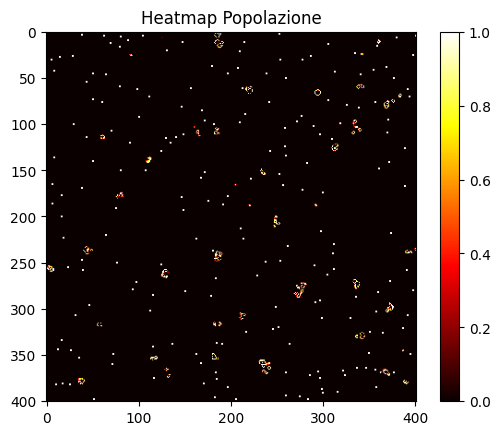

In [252]:
import matplotlib.pyplot as plt
import numpy as np
import popolazione as pop
import importlib
importlib.reload(pop)
STORICO, POPOLAZIONE = pop.esperimento(150)

print(f"Giorno 100 (pre-lockdown): {STORICO[100].mean():.4f}")
print(f"Giorno 115 (lockdown):     {STORICO[115].mean():.4f}")
print(f"Giorno 130 (lockdown):     {STORICO[130].mean():.4f}")

STORICO, POPOLAZIONE = pop.esperimento(GIORNO_DA_STUDIARE)
plt.imshow(POPOLAZIONE[0], cmap='hot')
plt.colorbar()
plt.title('Heatmap Popolazione')
plt.savefig("30 marzo")
plt.show()

In [ ]:
import virus as vir
import importlib 
importlib.reload(vir)

N, VIRUS_LAYERS = vir.setup_virus(GIORNO_DA_STUDIARE, STORICO)

# Visualizza l'ultimo giorno con scala fissa 0-900
plt.imshow(VIRUS_LAYERS[-1], cmap='hot', vmin=0, vmax=900)
plt.colorbar()
plt.title('Heatmap VIRUS ultimo giorno')
plt.show()


s=0.341
x = np.arange(1, 32)
pesi = vir.P(x)

infezioni_giornaliere = N.sum(axis=(1, 2))

# Ogni cella = 416 persone, ma il fattore s già tiene conto della scala
# quindi basta dividere per il numero di celle
infezioni_giornaliere = infezioni_giornaliere / (416)

morti_simulati = np.convolve(infezioni_giornaliere, pesi)[:len(infezioni_giornaliere)]
morti_scalati  = morti_simulati * s

plt.plot(morti_scalati)


c:\Users\Loryb\Metodi-Computazionali\Metodi-Computazionali\progetto\virus.py:72: RuntimeWarning: divide by zero encountered in divide
  scala = np.where(eccesso_mask, Vm / totale, 1.0)


[1, 0]


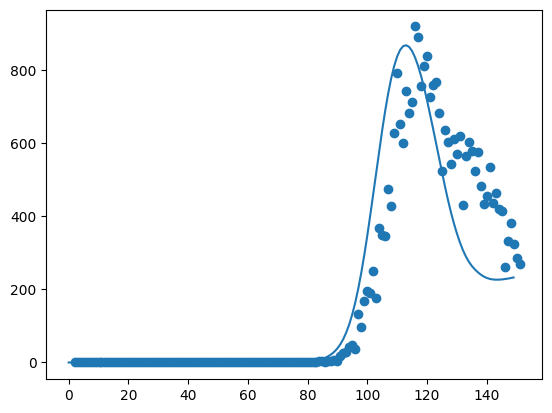

[  2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.
  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.  29.
  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.
  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.
  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.
  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.
  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.  99.
 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126. 127.
 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140. 141.
 142. 143. 144. 145. 146. 147. 148. 149. 150. 151.] [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   

In [ ]:
import pandas as pd
df = pd.read_excel("itacovid.ods")

print(df.columns.tolist())

X = df.iloc[:GIORNO_DA_STUDIARE,0].to_numpy()
Y = df.iloc[:GIORNO_DA_STUDIARE,1].to_numpy()

plt.scatter(X,Y)
plt.plot(morti_scalati)
plt.show()
print(X,Y)

# TODO : Trovare una ragazza (facoltativo) 

